Mounted at /content/drive
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  

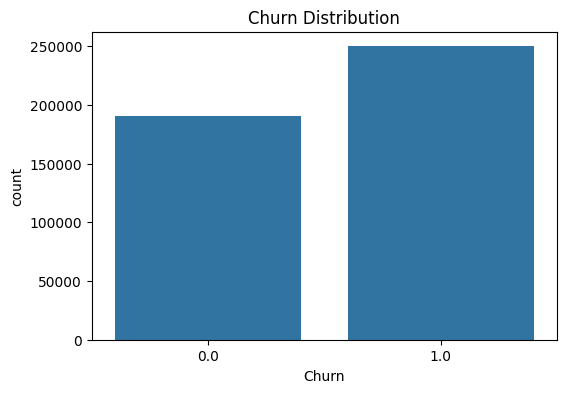

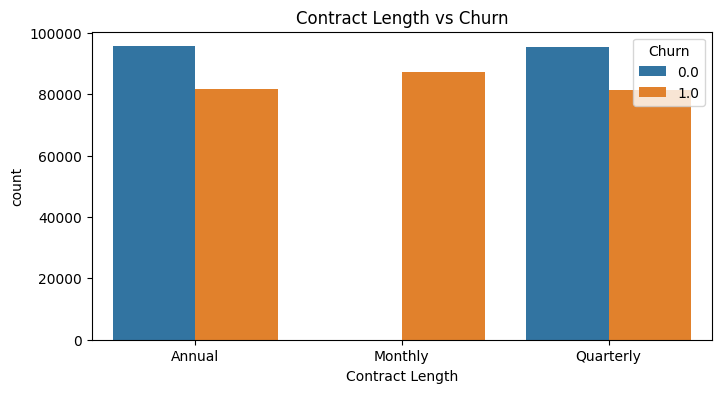

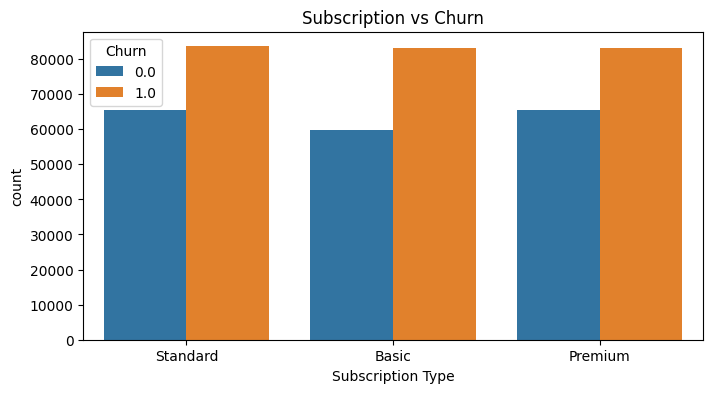

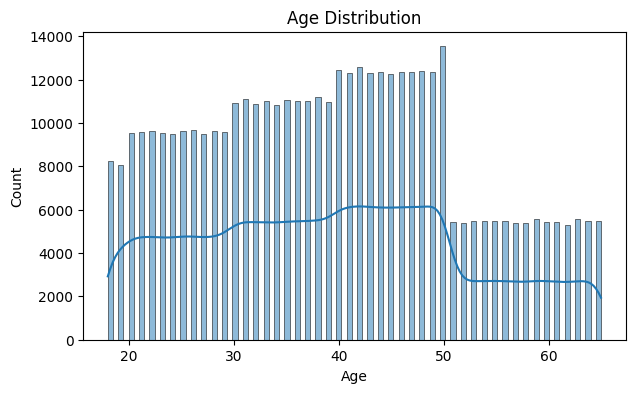

Training started...
Training completed

Accuracy: 99.93 %
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



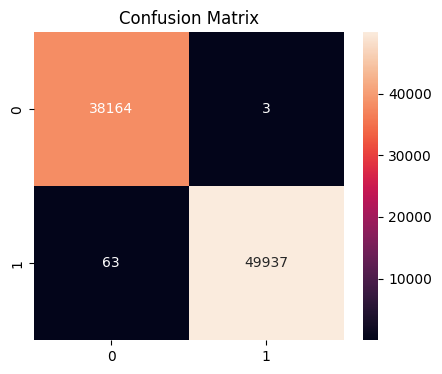


Enter Customer Details
Age: 45
Gender: 1
Tenure: 2
Usage Frequency: 3
Support Calls: 8
Payment Delay: 30
Subscription Type: 0
Contract Length: 0
Total Spend: 290
Last Interaction: 20

CHURN : YES
Churn Probability: 100.0 %

RECOMMENDATION:

- Contact customer
- Give discount offer
- Provide better support
- Offer loyalty plan
- Improve customer experience

        


In [ ]:
# =====================================
# CUSTOMER CHURN PREDICTION
# GOOGLE COLAB COMPLETE CODE
# FAST VERSION
# =====================================


# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline


from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)



# =====================================
# CONNECT GOOGLE DRIVE
# =====================================

from google.colab import drive

drive.mount('/content/drive')



# =====================================
# LOAD DATA
# =====================================


train_df = pd.read_csv(
    "/content/drive/MyDrive/Dataset1/customer_churn_dataset-training-master.csv"
)


test_df = pd.read_csv(
    "/content/drive/MyDrive/Dataset1/customer_churn_dataset-testing-master.csv"
)


print(train_df.head())

print(train_df.shape)



# =====================================
# DATA CLEANING
# =====================================


train_df.drop_duplicates(inplace=True)

train_df.dropna(inplace=True)


print("Cleaned Data Shape")

print(train_df.shape)



# =====================================
# DATA VISUALIZATION
# =====================================


plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=train_df
)

plt.title("Churn Distribution")

plt.show()



plt.figure(figsize=(8,4))

sns.countplot(
    x="Contract Length",
    hue="Churn",
    data=train_df
)

plt.title("Contract Length vs Churn")

plt.show()



plt.figure(figsize=(8,4))

sns.countplot(
    x="Subscription Type",
    hue="Churn",
    data=train_df
)

plt.title("Subscription vs Churn")

plt.show()



plt.figure(figsize=(7,4))

sns.histplot(
    train_df["Age"],
    kde=True
)

plt.title("Age Distribution")

plt.show()



# =====================================
# INPUT AND OUTPUT
# =====================================


X = train_df.drop(
    [
        "Churn",
        "CustomerID"
    ],
    axis=1
)


y = train_df["Churn"]




# =====================================
# TRAIN TEST SPLIT
# =====================================


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)




# =====================================
# ENCODING
# =====================================


cat_columns = X.select_dtypes(
    include="object"
).columns



num_columns = X.select_dtypes(
    exclude="object"
).columns




preprocessor = ColumnTransformer(

[
    (
    "categorical",
    OneHotEncoder(
        handle_unknown="ignore"
    ),
    cat_columns
    ),


    (
    "numerical",
    StandardScaler(),
    num_columns
    )

]

)




# =====================================
# RANDOM FOREST MODEL
# =====================================


rf = RandomForestClassifier(

    n_estimators=250,

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)




model = Pipeline(

[
("preprocess",preprocessor),

("randomforest",rf)

]

)



# =====================================
# TRAIN MODEL
# =====================================


print("Training started...")


model.fit(
    X_train,
    y_train
)


print("Training completed")



# =====================================
# TESTING
# =====================================


y_pred = model.predict(
    X_test
)



accuracy = accuracy_score(
    y_test,
    y_pred
)



print(
"\nAccuracy:",
round(accuracy*100,2),
"%"
)



print(
classification_report(
    y_test,
    y_pred
)
)




# =====================================
# CONFUSION MATRIX
# =====================================


cm = confusion_matrix(
    y_test,
    y_pred
)



plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()




# =====================================
# CUSTOMER PREDICTION
# =====================================


def predict_customer():


    print("\nEnter Customer Details")


    customer = {


    "Age":[
        float(input("Age: "))
    ],


    "Gender":[
        input("Gender: ")
    ],


    "Tenure":[
        float(input("Tenure: "))
    ],


    "Usage Frequency":[
        float(input("Usage Frequency: "))
    ],


    "Support Calls":[
        float(input("Support Calls: "))
    ],


    "Payment Delay":[
        float(input("Payment Delay: "))
    ],


    "Subscription Type":[
        input("Subscription Type: ")
    ],


    "Contract Length":[
        input("Contract Length: ")
    ],


    "Total Spend":[
        float(input("Total Spend: "))
    ],


    "Last Interaction":[
        float(input("Last Interaction: "))
    ]


    }



    customer_df = pd.DataFrame(customer)



    result = model.predict(
        customer_df
    )


    probability = model.predict_proba(
        customer_df
    )[0][1]




    if result[0]==1:


        print("\nCHURN : YES")


        print(
        "Churn Probability:",
        round(probability*100,2),
        "%"
        )


        print(
        """
RECOMMENDATION:

- Contact customer
- Give discount offer
- Provide better support
- Offer loyalty plan
- Improve customer experience

        """
        )



    else:


        print("\nCHURN : NO")


        print(
        "Churn Probability:",
        round(probability*100,2),
        "%"
        )


        print(
        """
RECOMMENDATION:

- Continue current service
- Maintain relationship
- Provide premium offers

        """
        )




predict_customer()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0           

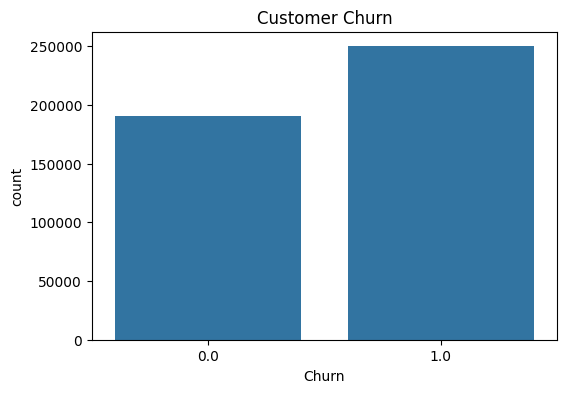

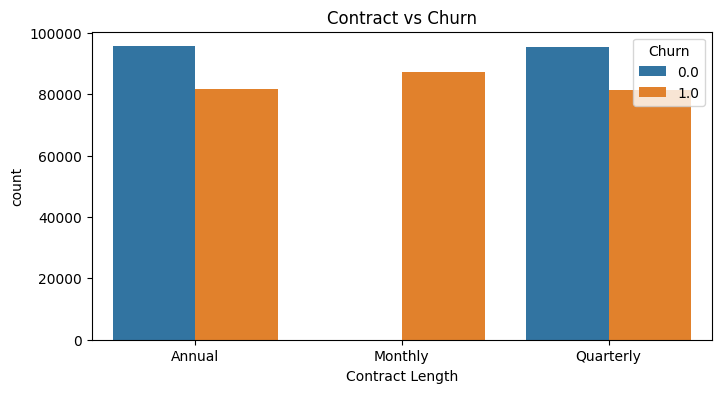

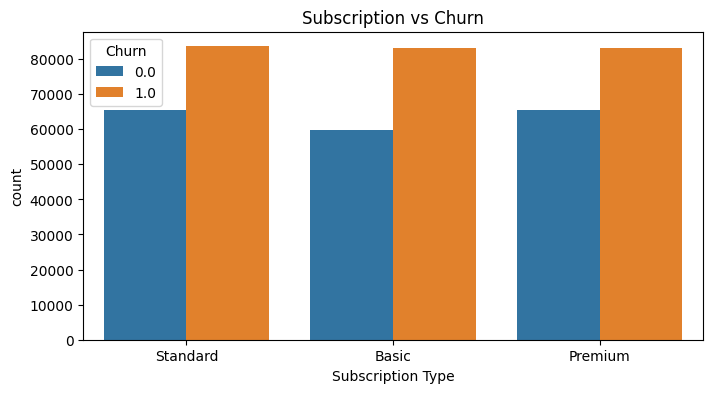

Training started...
Training completed

Accuracy: 89.46 %
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.88     38167
         1.0       0.94      0.87      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.90     88167



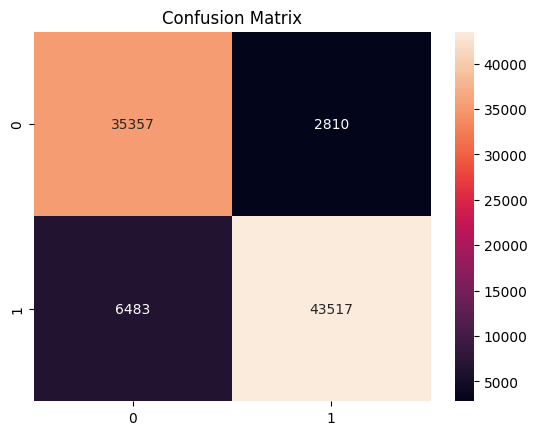


Enter Customer Details
Age: 45
Gender: 1
Tenure: 2
Usage Frequency: 3
Support Calls: 8
Payment Delay: 30
Subscription Type: 0
Contract Length: 0
Total Spend: 200
Last Interaction: 20

CUSTOMER CHURN : YES
Churn Probability: 100.0 %

RECOMMENDATION:

✔ Call customer
✔ Give discount offer
✔ Provide loyalty benefits
✔ Improve support service
✔ Offer better subscription

        


In [ ]:
# ============================================
# CUSTOMER CHURN PREDICTION
# LOGISTIC REGRESSION HIGH ACCURACY VERSION
# ============================================
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
# ============================================
# DRIVE
# ============================================

drive.mount('/content/drive')

# ============================================
# LOAD DATA
# ============================================

train_df = pd.read_csv(
    "/content/drive/MyDrive/Dataset1/customer_churn_dataset-training-master.csv"
)


test_df = pd.read_csv(
    "/content/drive/MyDrive/Dataset1/customer_churn_dataset-testing-master.csv"
)
print(train_df.head())
print(train_df.shape)

# ============================================
# DATA CLEANING
# ============================================

train_df.drop_duplicates(inplace=True)

train_df.dropna(inplace=True)

print(train_df.shape)

# ============================================
# EDA
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(
    x="Churn",
    data=train_df
)
plt.title("Customer Churn")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(
    x="Contract Length",
    hue="Churn",
    data=train_df
)
plt.title("Contract vs Churn")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(
    x="Subscription Type",
    hue="Churn",
    data=train_df
)
plt.title("Subscription vs Churn")
plt.show()

# ============================================
# INPUT OUTPUT
# ============================================

X = train_df.drop(
    [
    "Churn",
    "CustomerID"
    ],
    axis=1
)
y = train_df["Churn"]

# ============================================
# SPLIT
# ============================================

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================
# PREPROCESSING
# ============================================

cat_cols = X.select_dtypes(
    include="object"
).columns

num_cols = X.select_dtypes(
    exclude="object"
).columns

preprocessor = ColumnTransformer(

[
("categorical",
 OneHotEncoder(
     handle_unknown="ignore"
 ),
 cat_cols),


("numerical",
 StandardScaler(),
 num_cols)
]
)

# ============================================
# LOGISTIC REGRESSION MODEL
# ============================================

log_model = LogisticRegression(

    max_iter=2000,

    C=1.5,

    class_weight="balanced",

    solver="liblinear"

)
model = Pipeline(

[
("preprocess",preprocessor),

("logistic",log_model)
]
)

# ============================================
# TRAIN
# ============================================

print("Training started...")


model.fit(
    X_train,
    y_train
)
print("Training completed")

# ============================================
# TEST
# ============================================

y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
"\nAccuracy:",
round(accuracy*100,2),
"%"
)

print(
classification_report(
    y_test,
    y_pred
)
)

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.title("Confusion Matrix")
plt.show()

# ============================================
# CUSTOMER INPUT PREDICTION
# ============================================

def predict_customer():

    print("\nEnter Customer Details")



    customer={


    "Age":[
        float(input("Age: "))
    ],


    "Gender":[
        input("Gender: ")
    ],


    "Tenure":[
        float(input("Tenure: "))
    ],


    "Usage Frequency":[
        float(input("Usage Frequency: "))
    ],


    "Support Calls":[
        float(input("Support Calls: "))
    ],


    "Payment Delay":[
        float(input("Payment Delay: "))
    ],


    "Subscription Type":[
        input("Subscription Type: ")
    ],


    "Contract Length":[
        input("Contract Length: ")
    ],


    "Total Spend":[
        float(input("Total Spend: "))
    ],


    "Last Interaction":[
        float(input("Last Interaction: "))
    ]


    }



    customer_df=pd.DataFrame(customer)



    result=model.predict(
        customer_df
    )


    probability=model.predict_proba(
        customer_df
    )[0][1]




    if result[0]==1:


        print("\nCUSTOMER CHURN : YES")


        print(
        "Churn Probability:",
        round(probability*100,2),
        "%"
        )



        print(
        """
RECOMMENDATION:

✔ Call customer
✔ Give discount offer
✔ Provide loyalty benefits
✔ Improve support service
✔ Offer better subscription

        """
        )



    else:


        print("\nCUSTOMER CHURN : NO")


        print(
        "Churn Probability:",
        round(probability*100,2),
        "%"
        )


        print(
        """
RECOMMENDATION:

✔ Maintain customer
✔ Continue service
✔ Provide offers

        """
        )



predict_customer()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0           

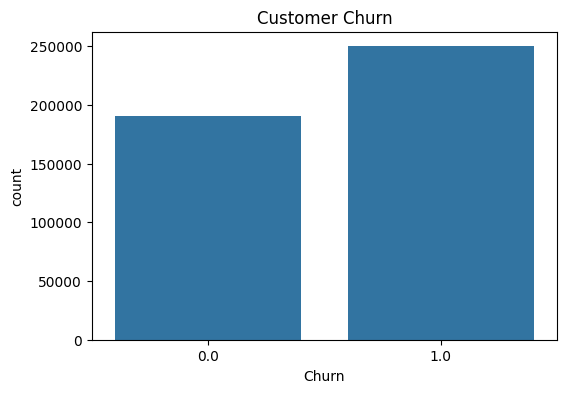

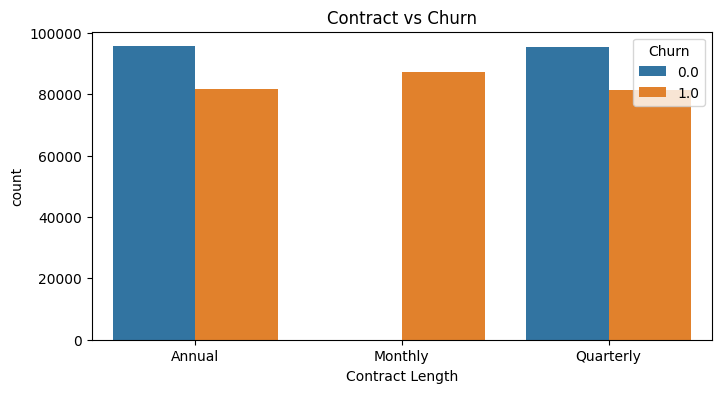

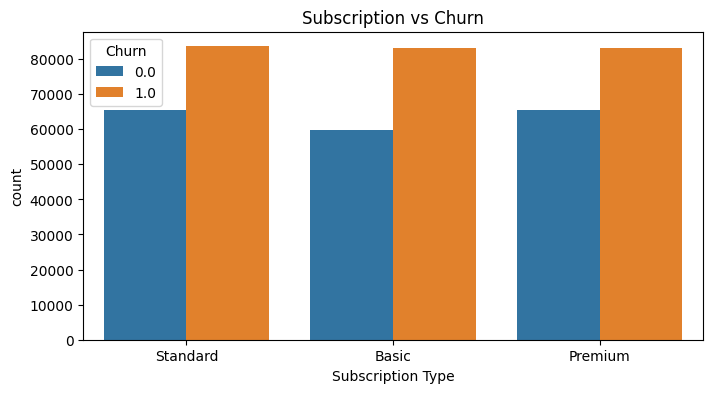

Training started...
Training completed

Accuracy: 89.46 %
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.88     38167
         1.0       0.94      0.87      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.90     88167



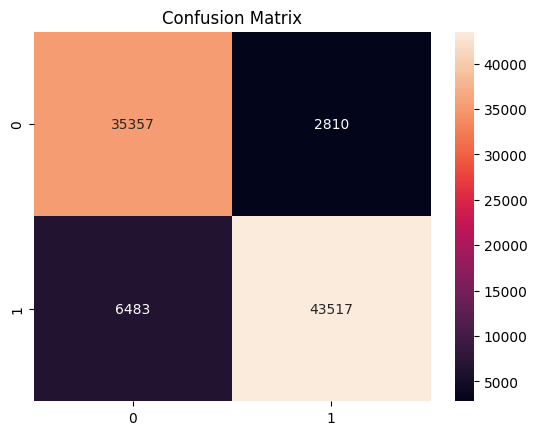


Enter Customer Details
Age: 45
Gender: 1
Tenure: 2
Usage Frequency: 3
Support Calls: 8
Payment Delay: 30
Subscription Type: 0
Contract Length: 0
Total Spend: 200
Last Interaction: 20

CUSTOMER CHURN : YES
Churn Probability: 100.0 %

RECOMMENDATION:

✔ Call customer
✔ Give discount offer
✔ Provide loyalty benefits
✔ Improve support service
✔ Offer better subscription

        


In [ ]:
# ============================================
# CUSTOMER CHURN PREDICTION
# LOGISTIC REGRESSION HIGH ACCURACY VERSION
# ============================================


# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)



# ============================================
# DRIVE
# ============================================

drive.mount('/content/drive')



# ============================================
# LOAD DATA
# ============================================


train_df = pd.read_csv(
    "/content/drive/MyDrive/Dataset1/customer_churn_dataset-training-master.csv"
)


test_df = pd.read_csv(
    "/content/drive/MyDrive/Dataset1/customer_churn_dataset-testing-master.csv"
)



print(train_df.head())

print(train_df.shape)



# ============================================
# DATA CLEANING
# ============================================


train_df.drop_duplicates(inplace=True)

train_df.dropna(inplace=True)



print(train_df.shape)



# ============================================
# EDA
# ============================================


plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=train_df
)

plt.title("Customer Churn")

plt.show()



plt.figure(figsize=(8,4))

sns.countplot(
    x="Contract Length",
    hue="Churn",
    data=train_df
)

plt.title("Contract vs Churn")

plt.show()



plt.figure(figsize=(8,4))

sns.countplot(
    x="Subscription Type",
    hue="Churn",
    data=train_df
)

plt.title("Subscription vs Churn")

plt.show()



# ============================================
# INPUT OUTPUT
# ============================================


X = train_df.drop(
    [
    "Churn",
    "CustomerID"
    ],
    axis=1
)


y = train_df["Churn"]



# ============================================
# SPLIT
# ============================================


X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)




# ============================================
# PREPROCESSING
# ============================================


cat_cols = X.select_dtypes(
    include="object"
).columns



num_cols = X.select_dtypes(
    exclude="object"
).columns




preprocessor = ColumnTransformer(

[
("categorical",
 OneHotEncoder(
     handle_unknown="ignore"
 ),
 cat_cols),


("numerical",
 StandardScaler(),
 num_cols)

]

)



# ============================================
# LOGISTIC REGRESSION MODEL
# ============================================


log_model = LogisticRegression(

    max_iter=2000,

    C=1.5,

    class_weight="balanced",

    solver="liblinear"

)




model = Pipeline(

[
("preprocess",preprocessor),

("logistic",log_model)

]

)



# ============================================
# TRAIN
# ============================================


print("Training started...")


model.fit(
    X_train,
    y_train
)


print("Training completed")




# ============================================
# TEST
# ============================================


y_pred = model.predict(
    X_test
)



accuracy = accuracy_score(
    y_test,
    y_pred
)



print(
"\nAccuracy:",
round(accuracy*100,2),
"%"
)



print(
classification_report(
    y_test,
    y_pred
)
)




# ============================================
# CONFUSION MATRIX
# ============================================


cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.title("Confusion Matrix")

plt.show()




# ============================================
# CUSTOMER INPUT PREDICTION
# ============================================


def predict_customer():


    print("\nEnter Customer Details")



    customer={


    "Age":[
        float(input("Age: "))
    ],


    "Gender":[
        input("Gender: ")
    ],


    "Tenure":[
        float(input("Tenure: "))
    ],


    "Usage Frequency":[
        float(input("Usage Frequency: "))
    ],


    "Support Calls":[
        float(input("Support Calls: "))
    ],


    "Payment Delay":[
        float(input("Payment Delay: "))
    ],


    "Subscription Type":[
        input("Subscription Type: ")
    ],


    "Contract Length":[
        input("Contract Length: ")
    ],


    "Total Spend":[
        float(input("Total Spend: "))
    ],


    "Last Interaction":[
        float(input("Last Interaction: "))
    ]


    }



    customer_df=pd.DataFrame(customer)



    result=model.predict(
        customer_df
    )


    probability=model.predict_proba(
        customer_df
    )[0][1]




    if result[0]==1:


        print("\nCUSTOMER CHURN : YES")


        print(
        "Churn Probability:",
        round(probability*100,2),
        "%"
        )



        print(
        """
RECOMMENDATION:

✔ Call customer
✔ Give discount offer
✔ Provide loyalty benefits
✔ Improve support service
✔ Offer better subscription

        """
        )



    else:


        print("\nCUSTOMER CHURN : NO")


        print(
        "Churn Probability:",
        round(probability*100,2),
        "%"
        )


        print(
        """
RECOMMENDATION:

✔ Maintain customer
✔ Continue service
✔ Provide offers

        """
        )



predict_customer()

In [ ]:
# Decision Tree

print(
"Training Accuracy:",
model.score(X_train, y_train)
)


print(
"Testing Accuracy:",
model.score(X_test, y_test)
)

Training Accuracy: 0.8964598131371131
Testing Accuracy: 0.8945977519933762


In [ ]:
# ==========================================
# RANDOM FOREST + LOGISTIC REGRESSION
# TRAINING & TESTING ACCURACY
# ==========================================


from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score



# -----------------------------
# COPY DATA
# -----------------------------

X = train_df.drop(
    ["Churn","CustomerID"],
    axis=1
)

y = train_df["Churn"]



# -----------------------------
# LABEL ENCODING
# -----------------------------

encoder = LabelEncoder()


for col in X.select_dtypes(include="object").columns:

    X[col] = encoder.fit_transform(
        X[col]
    )



# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



# -----------------------------
# SCALING
# -----------------------------

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)




# ==================================
# RANDOM FOREST
# ==================================


rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=20,

    random_state=42,

    class_weight="balanced",

    n_jobs=-1

)



rf_model.fit(
    X_train_scaled,
    y_train
)



rf_train_pred = rf_model.predict(
    X_train_scaled
)


rf_test_pred = rf_model.predict(
    X_test_scaled
)



rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_pred
)


rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)



print("==============================")
print("RANDOM FOREST")
print("==============================")


print(
"Training Accuracy:",
round(rf_train_accuracy*100,2),
"%"
)


print(
"Testing Accuracy:",
round(rf_test_accuracy*100,2),
"%"
)





# ==================================
# LOGISTIC REGRESSION
# ==================================


log_model = LogisticRegression(

    max_iter=2000,

    class_weight="balanced"

)



log_model.fit(
    X_train_scaled,
    y_train
)



log_train_pred = log_model.predict(
    X_train_scaled
)


log_test_pred = log_model.predict(
    X_test_scaled
)




log_train_accuracy = accuracy_score(
    y_train,
    log_train_pred
)



log_test_accuracy = accuracy_score(
    y_test,
    log_test_pred
)




print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")


print(
"Training Accuracy:",
round(log_train_accuracy*100,2),
"%"
)


print(
"Testing Accuracy:",
round(log_test_accuracy*100,2),
"%"
)

RANDOM FOREST
Training Accuracy: 100.0 %
Testing Accuracy: 99.98 %

LOGISTIC REGRESSION
Training Accuracy: 85.34 %
Testing Accuracy: 85.21 %
